# Compare qsoptex i200 CSV Results

This notebook compares two CSV files with `qsoptex_i200` benchmark results and highlights differences in:

- global time
- LP setup time
- LP running time
- number of iterations
- strict mode
- LP failures
- external calls

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

In [2]:
# Update these paths if your files move
base = Path('..')
csv_a = base / 'soplex_i200_strict_old.csv'
csv_b = base / 'soplex_i200_strict.csv'

print('CSV A:', csv_a.resolve())
print('CSV B:', csv_b.resolve())

CSV A: /home/campus.ncl.ac.uk/c3054737/Programming/phd/cvc5/soplex_i200_strict_old.csv
CSV B: /home/campus.ncl.ac.uk/c3054737/Programming/phd/cvc5/soplex_i200_strict.csv


In [3]:
def parse_ms_to_seconds(series: pd.Series) -> pd.Series:
    """Convert values like '27892ms' to seconds (27.892)."""
    s = series.astype(str).str.strip()
    ms = s.str.extract(r'^([0-9]+(?:\.[0-9]+)?)ms$')[0]
    out = pd.to_numeric(ms, errors='coerce') / 1000.0
    return out

def to_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors='coerce')

df_a = pd.read_csv(csv_a)
df_b = pd.read_csv(csv_b)

print('Rows A:', len(df_a), '| Rows B:', len(df_b))
print('Cols A:', len(df_a.columns), '| Cols B:', len(df_b.columns))

Rows A: 1712 | Rows B: 160
Cols A: 55 | Cols B: 58


In [4]:
# Standardize benchmark key (basename of file path)
def add_benchmark_key(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['benchmark'] = out['file'].astype(str).str.split('/').str[-1]
    return out

df_a = add_benchmark_key(df_a)
df_b = add_benchmark_key(df_b)

# Build LP failures metric from feasible+infeasible failures
for df in (df_a, df_b):
    df['lp_failures_total'] = (
        to_numeric(df.get('theory::arith::z::arith::relax::feasible::failures', 0))
        .fillna(0)
        + to_numeric(df.get('theory::arith::z::arith::relax::infeasible::failures', 0)).fillna(0)
    )

# Map requested metrics to columns
metric_cols = {
    'global_time_s': 'timeQ',
    'lp_setup_time_s': 'theory::arith::z::approx::lp::setup::timer',
    'lp_run_time_s': 'theory::arith::z::approx::lp::timer',
    'iterations': 'theory::arith::z::approx::refinements',
    'strict_mode': 'options::strict',
    'lp_failures': 'lp_failures_total',
    'external_calls': 'theory::arith::z::arith::relax::calls',
}

required = ['benchmark'] + list(metric_cols.values())
missing_a = [c for c in required if c not in df_a.columns]
missing_b = [c for c in required if c not in df_b.columns]
print('Missing in A:', missing_a)
print('Missing in B:', missing_b)

Missing in A: ['timeQ']
Missing in B: ['timeQ']


In [6]:
def build_metric_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame()
    out['benchmark'] = df['benchmark']
    out['global_time_s'] = to_numeric(df['timeS'])
    out['lp_setup_time_s'] = parse_ms_to_seconds(df['theory::arith::z::approx::lp::setup::timer'])
    out['lp_run_time_s'] = parse_ms_to_seconds(df['theory::arith::z::approx::lp::timer'])
    out['iterations'] = to_numeric(df['theory::arith::z::approx::refinements'])
    out['strict_mode'] = to_numeric(df['options::strict'])
    out['lp_failures'] = to_numeric(df['lp_failures_total'])
    out['external_calls'] = to_numeric(df['theory::arith::z::arith::relax::calls'])
    return out

m_a = build_metric_frame(df_a)
m_b = build_metric_frame(df_b)

merged = m_a.merge(m_b, on='benchmark', suffixes=('_old', '_new'), how='outer', indicator=True)
common = merged[merged['_merge'] == 'both'].copy()

print('Merged rows:', len(merged))
print('Only in A:', (merged['_merge'] == 'left_only').sum())
print('Only in B:', (merged['_merge'] == 'right_only').sum())
print('In both :', (merged['_merge'] == 'both').sum())
print('\nComparing metrics on shared benchmarks only:', len(common))

Merged rows: 1728
Only in A: 1568
Only in B: 16
In both : 144

Comparing metrics on shared benchmarks only: 144


In [7]:
# Compute deltas for requested metrics
metrics = [
    'global_time_s',
    'lp_setup_time_s',
    'lp_run_time_s',
    'iterations',
    'strict_mode',
    'lp_failures',
    'external_calls',
]

cmp = merged.copy()
cmp = common.copy()
for m in metrics:
    a = f'{m}_old'
    b = f'{m}_new'
    cmp[f'{m}_delta'] = cmp[b].fillna(0) - cmp[a].fillna(0)
    denom = cmp[a].replace(0, np.nan)
    cmp[f'{m}_pct'] = (cmp[f'{m}_delta'] / denom) * 100

# Any changed metric row-wise
delta_cols = [f'{m}_delta' for m in metrics]
cmp['any_change'] = cmp[delta_cols].fillna(0).ne(0).any(axis=1)

summary = pd.DataFrame({
    'changed_rows': [int(cmp['any_change'].sum())],
    'total_rows': [int(len(cmp))],
})
summary

,changed_rows,total_rows
0,144,144


In [8]:
# Per-metric difference summary
rows = []
for m in metrics:
    d = cmp[f'{m}_delta']
    changed = d.fillna(0).ne(0)
    rows.append({
        'metric': m,
        'changed_count': int(changed.sum()),
        'max_abs_delta': float(d.abs().max(skipna=True)) if d.notna().any() else np.nan,
        'mean_abs_delta': float(d.abs().mean(skipna=True)) if d.notna().any() else np.nan,
    })

metric_summary = pd.DataFrame(rows).sort_values(['changed_count', 'max_abs_delta'], ascending=False)
metric_summary

,metric,changed_count,max_abs_delta,mean_abs_delta
0,global_time_s,144,14723.825,688.081271
2,lp_run_time_s,133,1216.509,16.243056
1,lp_setup_time_s,133,320.837,8.230458
6,external_calls,82,35869.000,266.645833
5,lp_failures,11,764.000,5.493056
3,iterations,0,0.000,0.000000
4,strict_mode,0,0.000,0.000000


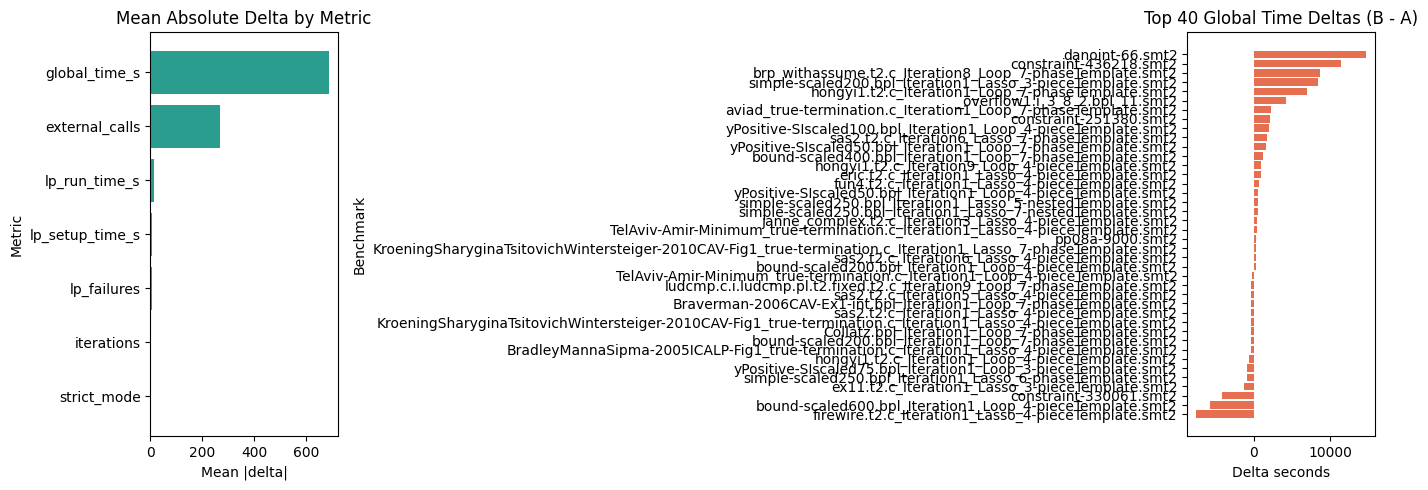

In [9]:
import matplotlib.pyplot as plt

# Plot 1: mean absolute delta per metric
plot_df = metric_summary.copy()
plot_df = plot_df.sort_values('mean_abs_delta', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(plot_df['metric'], plot_df['mean_abs_delta'], color='#2a9d8f')
axes[0].set_title('Mean Absolute Delta by Metric')
axes[0].set_xlabel('Mean |delta|')
axes[0].set_ylabel('Metric')

# Plot 2: top benchmarks by absolute global time delta
top_n = 40
top = cmp.sort_values('global_time_s_delta', key=lambda s: s.abs(), ascending=False).head(top_n).copy()
top = top.sort_values('global_time_s_delta', ascending=True)

axes[1].barh(top['benchmark'], top['global_time_s_delta'], color='#e76f51')
axes[1].set_title(f'Top {top_n} Global Time Deltas (B - A)')
axes[1].set_xlabel('Delta seconds')
axes[1].set_ylabel('Benchmark')

plt.tight_layout()
plt.show()

In [10]:
# Grouped bar plot: old vs new global time for each benchmark file
def print_bar(bar_df):
    bar_df = bar_df.copy()
    bar_df['max_time'] = bar_df[['global_time_s_old', 'global_time_s_new']].max(axis=1)
    bar_df = bar_df.sort_values('max_time', ascending=False).drop(columns=['max_time']).reset_index(drop=True)

    n = len(bar_df)
    y_pos = np.arange(n)
    bar_h = 0.4
    fig_h = max(10, n * 0.28)

    fig, ax = plt.subplots(figsize=(12, fig_h))
    ax.barh(y_pos - bar_h / 2, bar_df['global_time_s_old'], height=bar_h, color='#457b9d', label='old')
    ax.barh(y_pos + bar_h / 2, bar_df['global_time_s_new'], height=bar_h, color='#e63946', label='new')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(bar_df['benchmark'])
    ax.invert_yaxis()
    ax.set_xlabel('Global time [s]')
    ax.set_ylabel('Benchmark file')
    ax.set_title('Global Time per Benchmark: Old vs New')
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

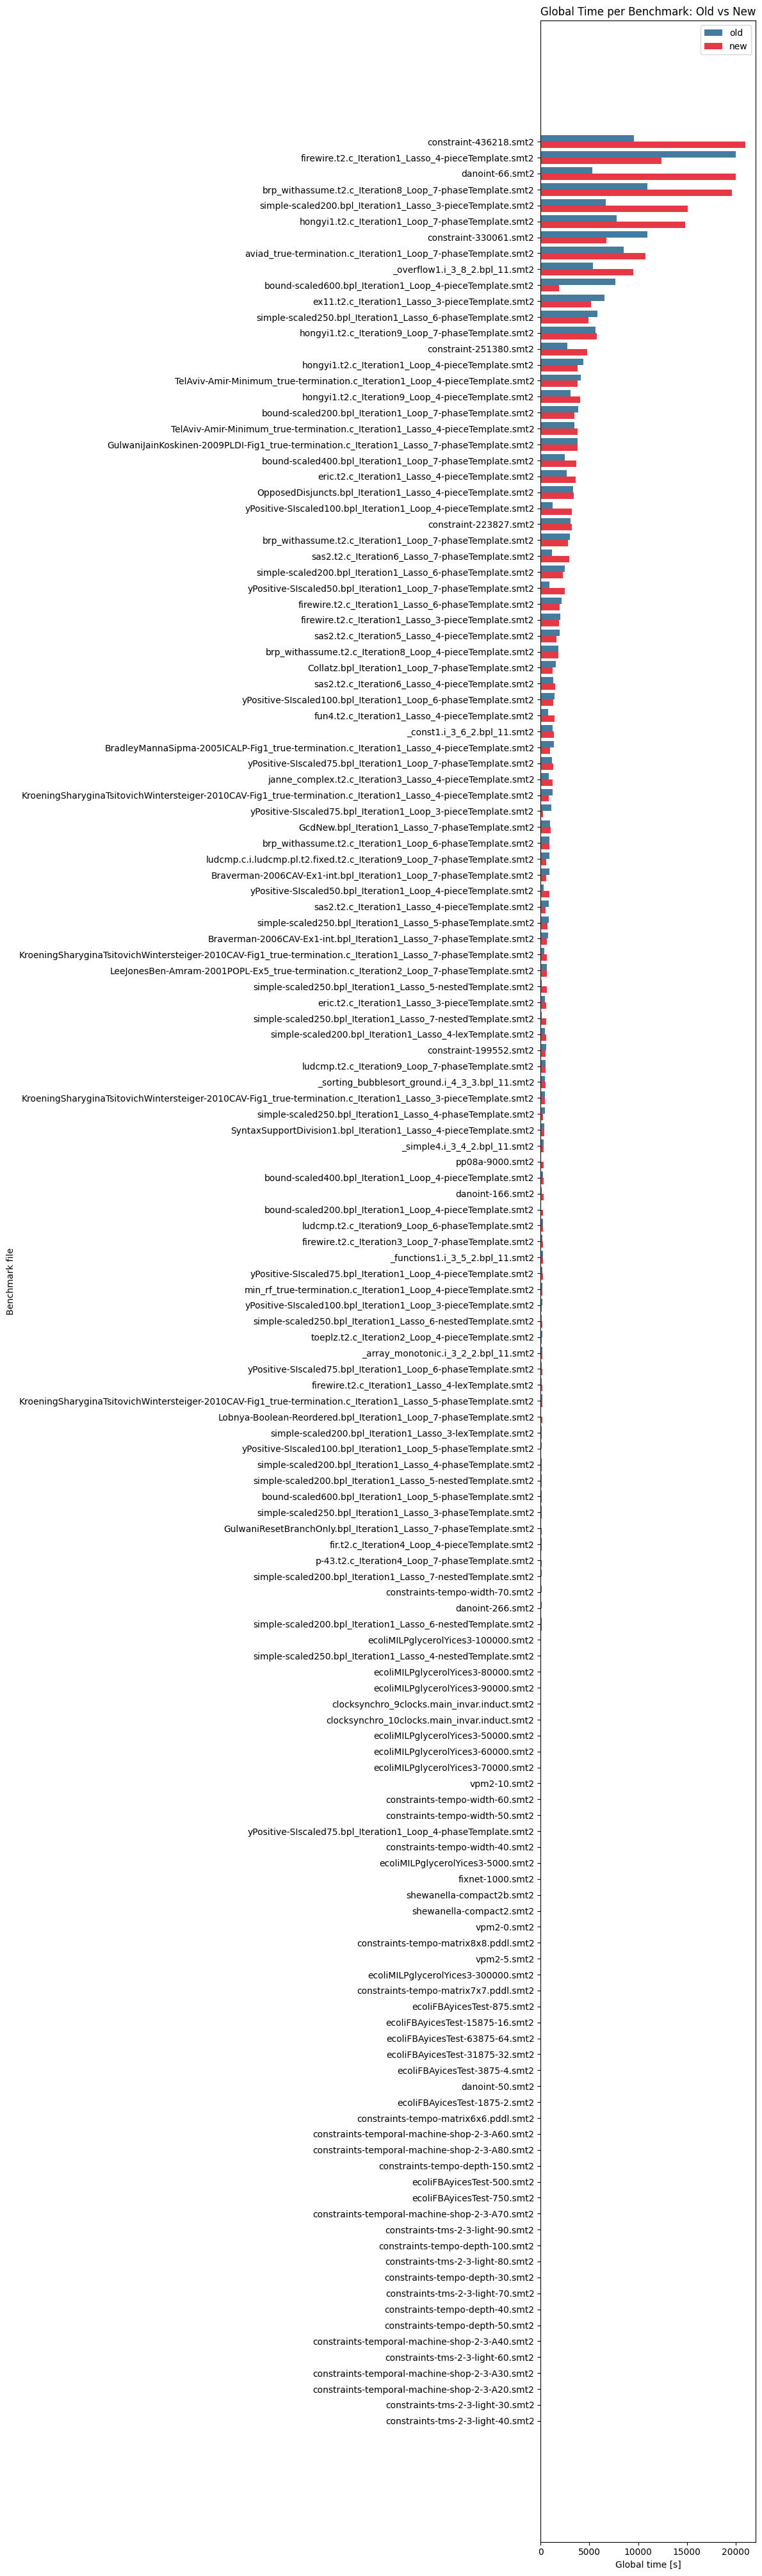

In [11]:
all_df = cmp[['benchmark', 'global_time_s_old', 'global_time_s_new']].dropna()
faster_new = all_df[all_df['global_time_s_new'] < all_df['global_time_s_old']]
faster_old = all_df[all_df['global_time_s_old'] < all_df['global_time_s_new']]
print_bar(all_df)

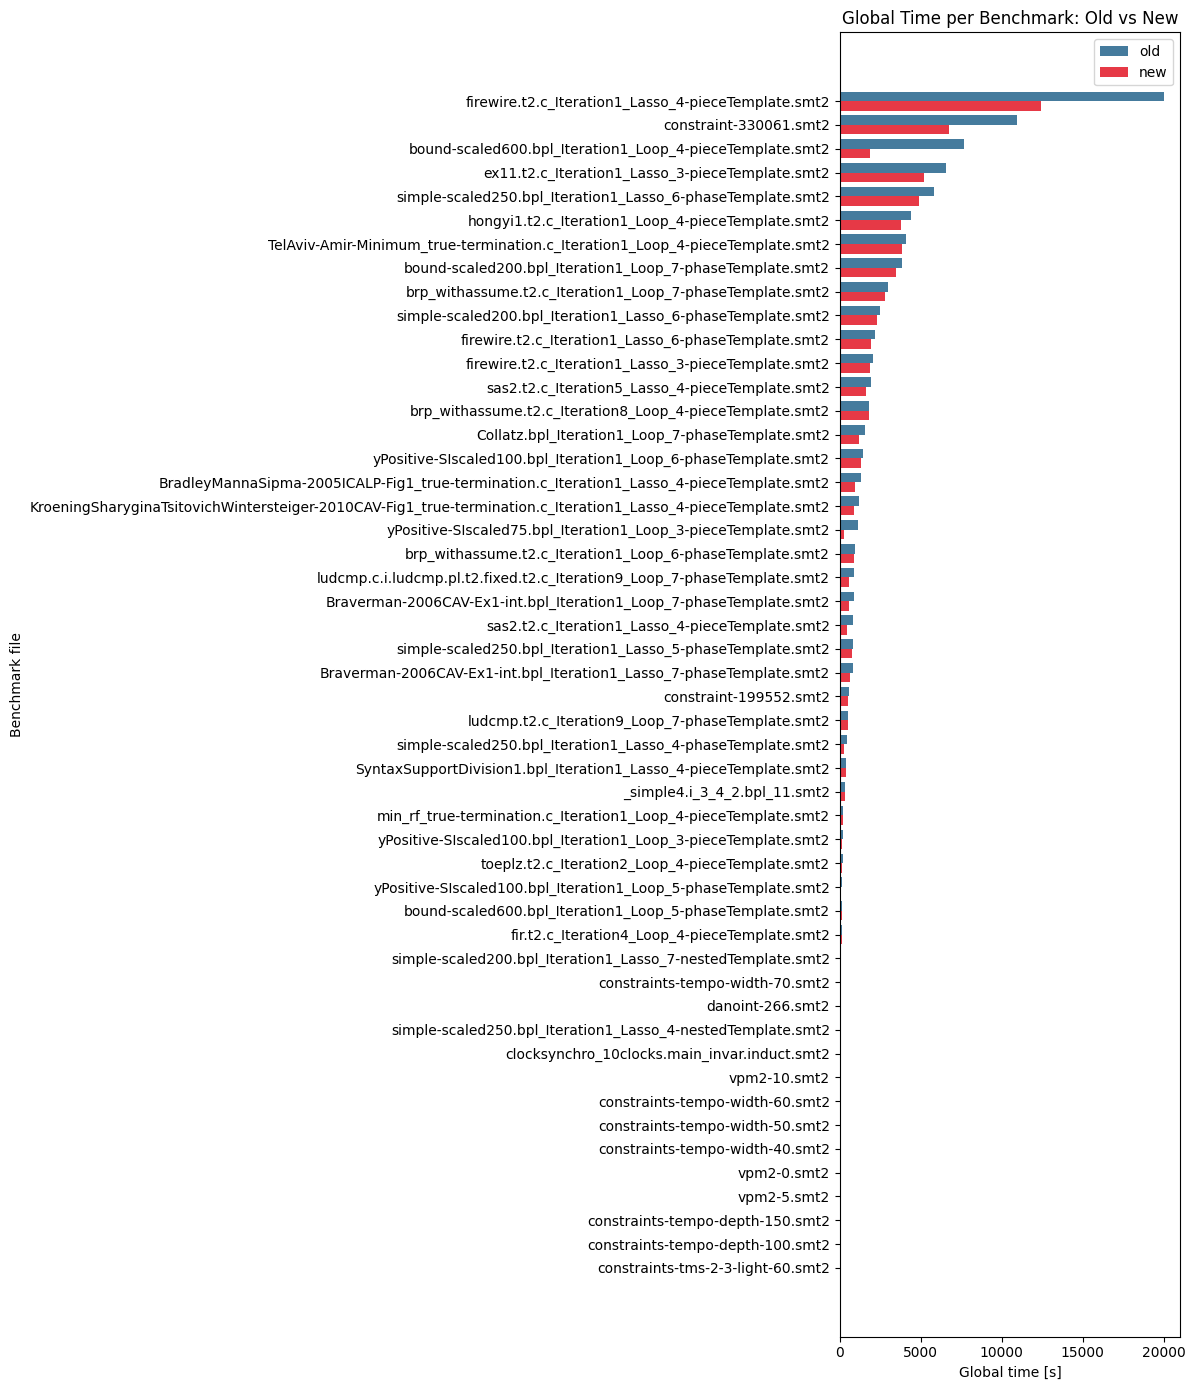

In [12]:
print_bar(faster_new)

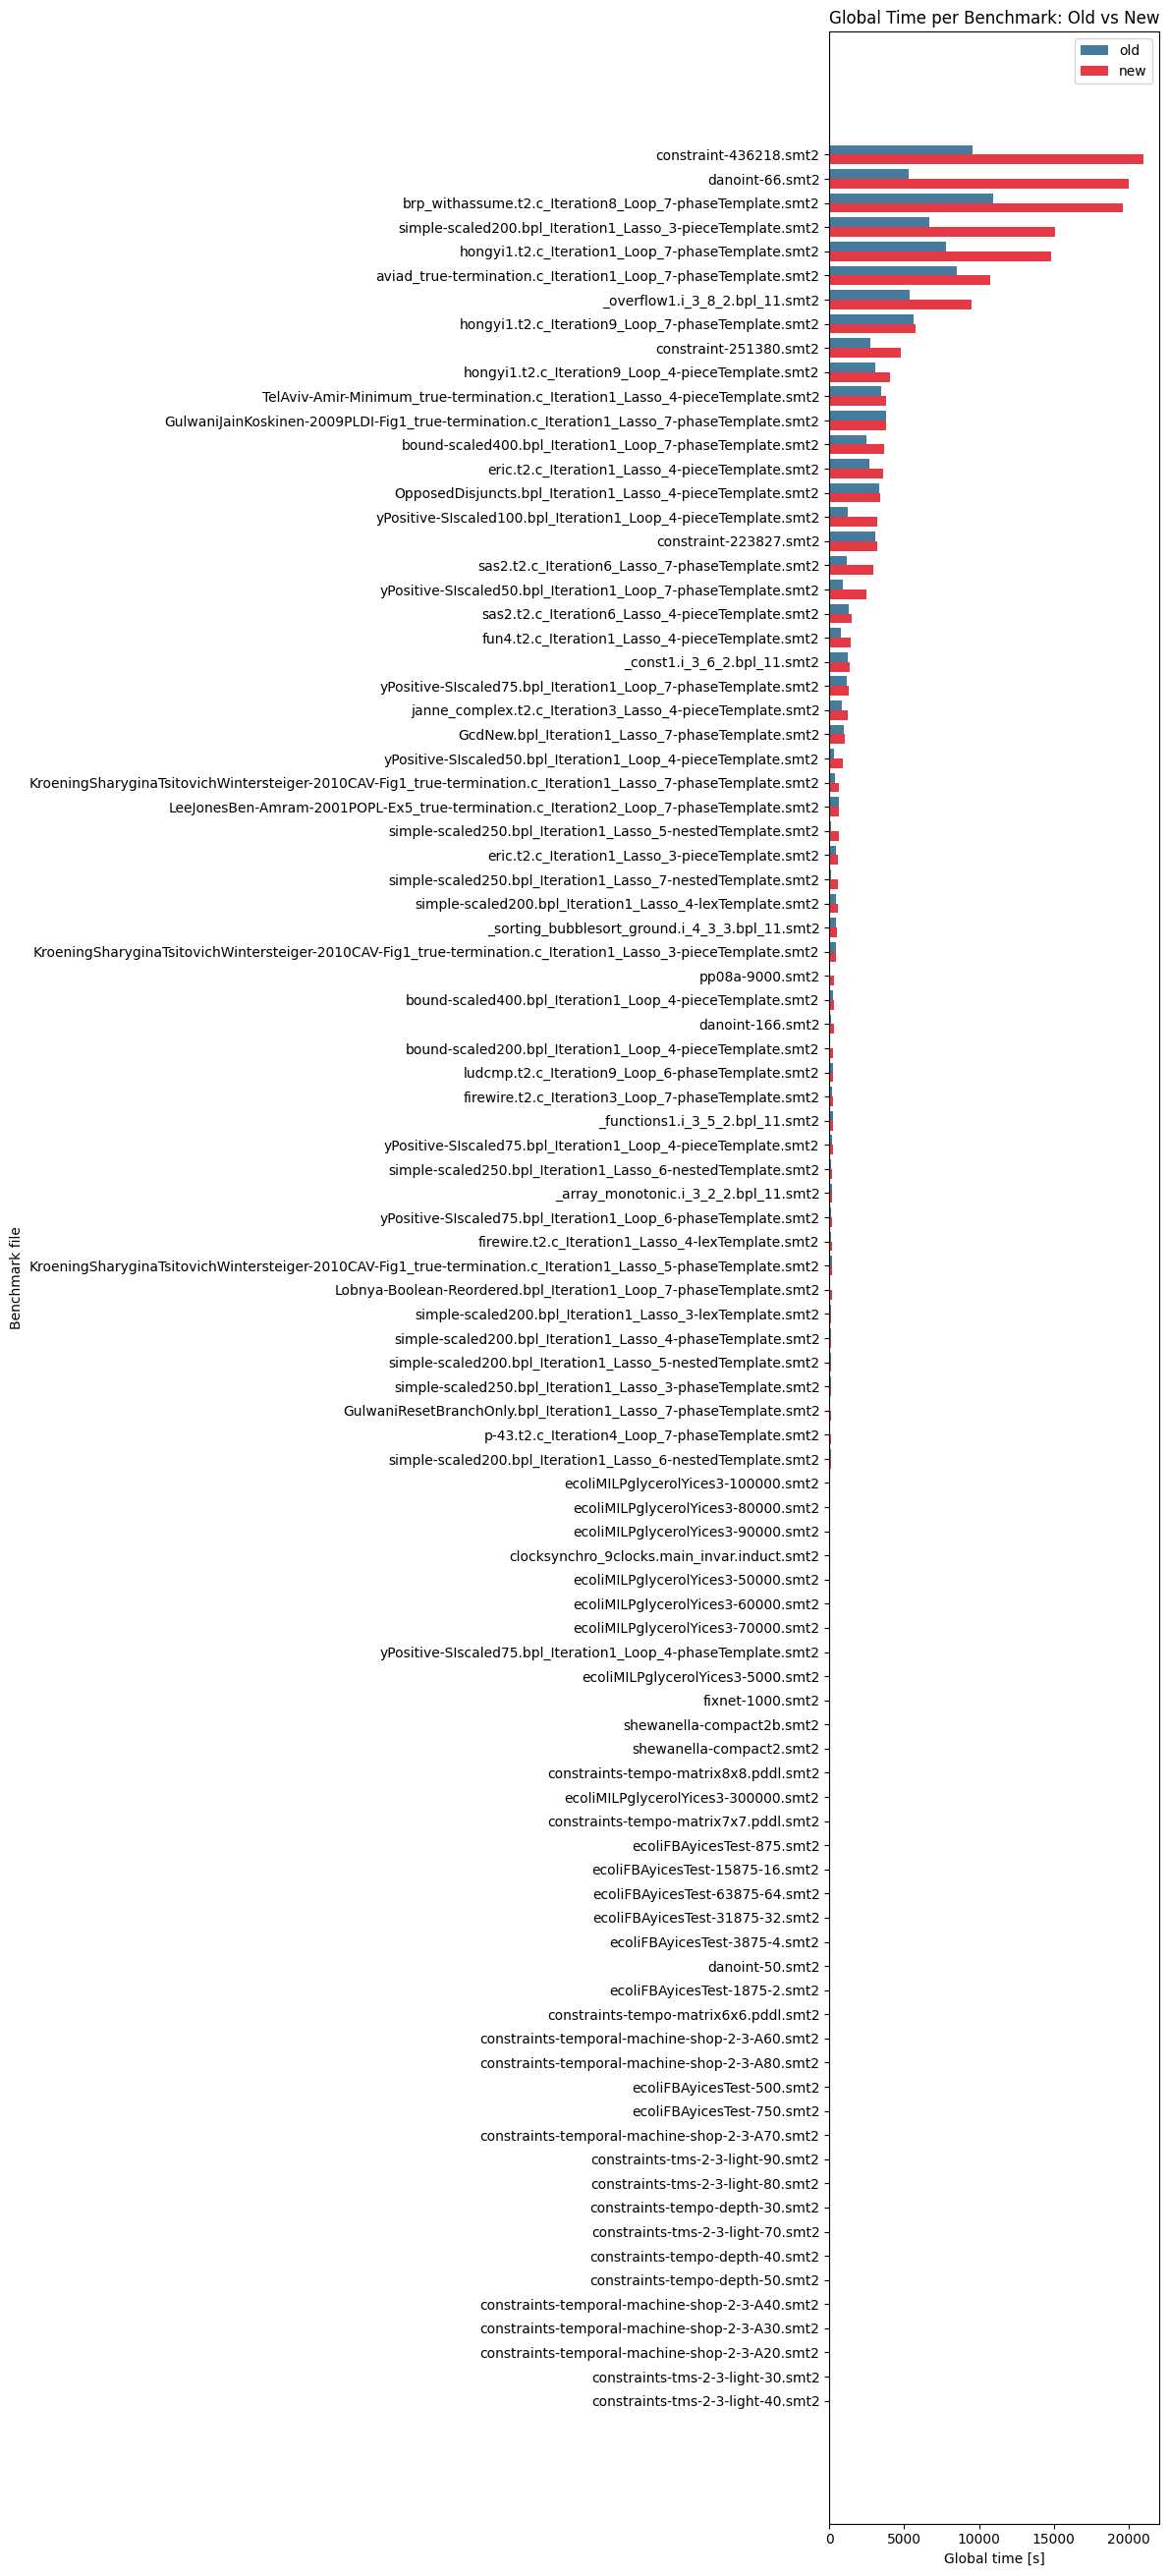

In [13]:
print_bar(faster_old)

## Optional: save detailed comparison

Uncomment and run the next line if you want to export all comparison rows.

`cmp.to_csv('qsoptex_i200_comparison.csv', index=False)`